In [26]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load raw Iris dataset
raw_iris = load_iris()
features = raw_iris.feature_names
X_raw = raw_iris.data
y_true = raw_iris.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Store in a DataFrame for visualization
iris_df = pd.DataFrame(data=X_scaled, columns=features)
iris_df['species_id'] = y_true
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}
iris_df['species_name'] = iris_df['species_id'].map(species_map)


In [28]:
import warnings
warnings.filterwarnings("ignore")

In [30]:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


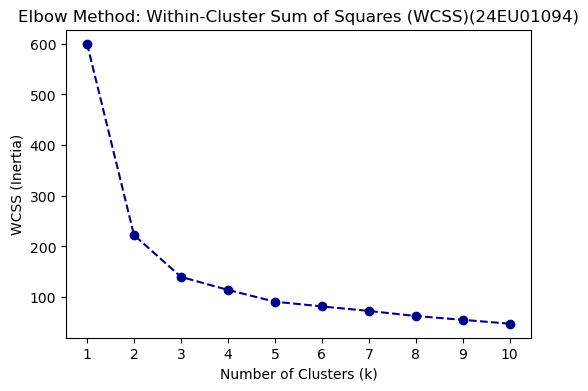

In [32]:
wcss = []
k_range = range(1, 11)


for k in k_range:  
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title("Elbow Method: Within-Cluster Sum of Squares (WCSS)(24EU01094)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.show()


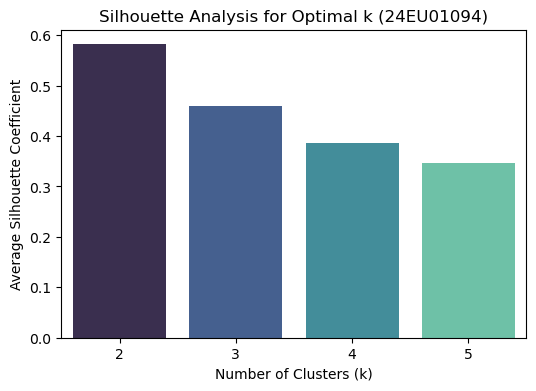

k = 2 yielded the highest silhouette coefficient (0.5818).


In [42]:
import seaborn as sns
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_eval = range(2, 6)


for k in k_eval:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)


plt.figure(figsize=(6, 4))
sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')
plt.title("Silhouette Analysis for Optimal k (24EU01094)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Coefficient")
plt.show()


best_k = k_eval[np.argmax(silhouette_scores)]
print(f"k = {best_k} yielded the highest silhouette coefficient ({max(silhouette_scores):.4f}).")


In [44]:

kmeans_raw = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)


iris_df['cluster_raw'] = kmeans_raw_labels
print("K-Means clustering complete. First 5 sample allocations:")
print(iris_df[['species_name', 'cluster_raw']].head(5))

K-Means clustering complete. First 5 sample allocations:
  species_name  cluster_raw
0       setosa            1
1       setosa            1
2       setosa            1
3       setosa            1
4       setosa            1


In [46]:

raw_centroids_scaled = kmeans_raw.cluster_centers_

raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)

centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=features)
centroids_df.index = [f"Cluster_{i}" for i in range(3)]

print("--- Estimated Cluster Centroids (Original Physical Units - cm) ---")
print(centroids_df)


--- Estimated Cluster Centroids (Original Physical Units - cm) ---
           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster_0           5.801887          2.673585           4.369811   
Cluster_1           5.006000          3.428000           1.462000   
Cluster_2           6.780851          3.095745           5.510638   

           petal width (cm)  
Cluster_0          1.413208  
Cluster_1          0.246000  
Cluster_2          1.972340  


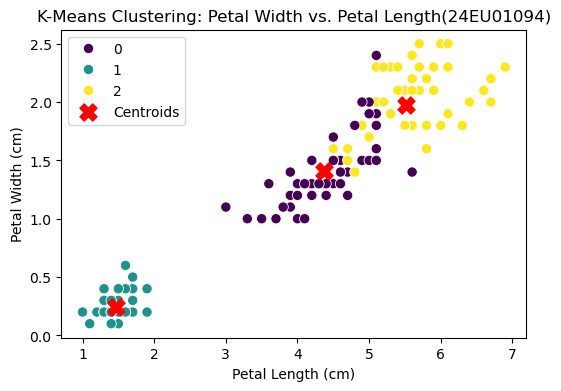

In [48]:
plt.figure(figsize=(6, 4))
raw_data = scaler.inverse_transform(X_scaled)
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')

plt.scatter(
    raw_centroids_physical[:, 2], 
    raw_centroids_physical[:, 3], 
    color='red', 
    marker='X', 
    s=150, 
    label='Centroids'
)

plt.title("K-Means Clustering: Petal Width vs. Petal Length(24EU01094)")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()